Column Details

1. **name**: Identifier for the subject or recording sample.
2. **MDVP:Fo(Hz)**: Fundamental frequency of voice in Hertz.
3. **MDVP:Fhi(Hz)**: Maximum fundamental frequency of voice in Hertz.
4. **MDVP:Flo(Hz)**: Minimum fundamental frequency of voice in Hertz.
5. **MDVP:Jitter(%)**: Variation in fundamental frequency as a percentage.
6. **MDVP:Jitter(Abs)**: Absolute variation in fundamental frequency.
7. **MDVP:RAP**: Relative amplitude perturbation, a jitter measurement.
8. **MDVP:PPQ**: Period perturbation quotient, another jitter measurement.
9. **Jitter:DDP**: Difference of differences of pitch periods, a jitter measure.
10. **MDVP:Shimmer**: Variation in the amplitude of voice.
11. **MDVP:Shimmer(dB)**: Shimmer measured in decibels.
12. **Shimmer:APQ3**: Amplitude perturbation quotient calculated over 3 periods.
13. **Shimmer:APQ5**: Amplitude perturbation quotient calculated over 5 periods.
14. **MDVP:APQ**: Amplitude perturbation quotient over all periods.
15. **Shimmer:DDA**: Average absolute difference of the amplitudes between consecutive periods.
16. **NHR**: Noise-to-harmonics ratio, indicating voice clarity.
17. **HNR**: Harmonics-to-noise ratio, a measure of voice quality.
18. **status**: Binary status of Parkinson's disease (1 for Parkinson's, 0 for healthy).
19. **RPDE**: Recurrence period density entropy, a nonlinear dynamical complexity measure.
20. **DFA**: Detrended fluctuation analysis, a measure of signal fractality.
21. **spread1**: Nonlinear measure of variation in the fundamental frequency.
22. **spread2**: Nonlinear measure of variation in voice amplitude.
23. **D2**: Dynamical complexity measure of the voice signal.
24. **PPE**: Pitch period entropy, reflecting voice signal regularity.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'/content/parkinsons.data')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [3]:
df.shape

(195, 24)

In [4]:
df.status.unique()

array([1, 0])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

We have only one object column that is also patients' identification so we can ignore that.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [7]:
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


Luckily no null values.

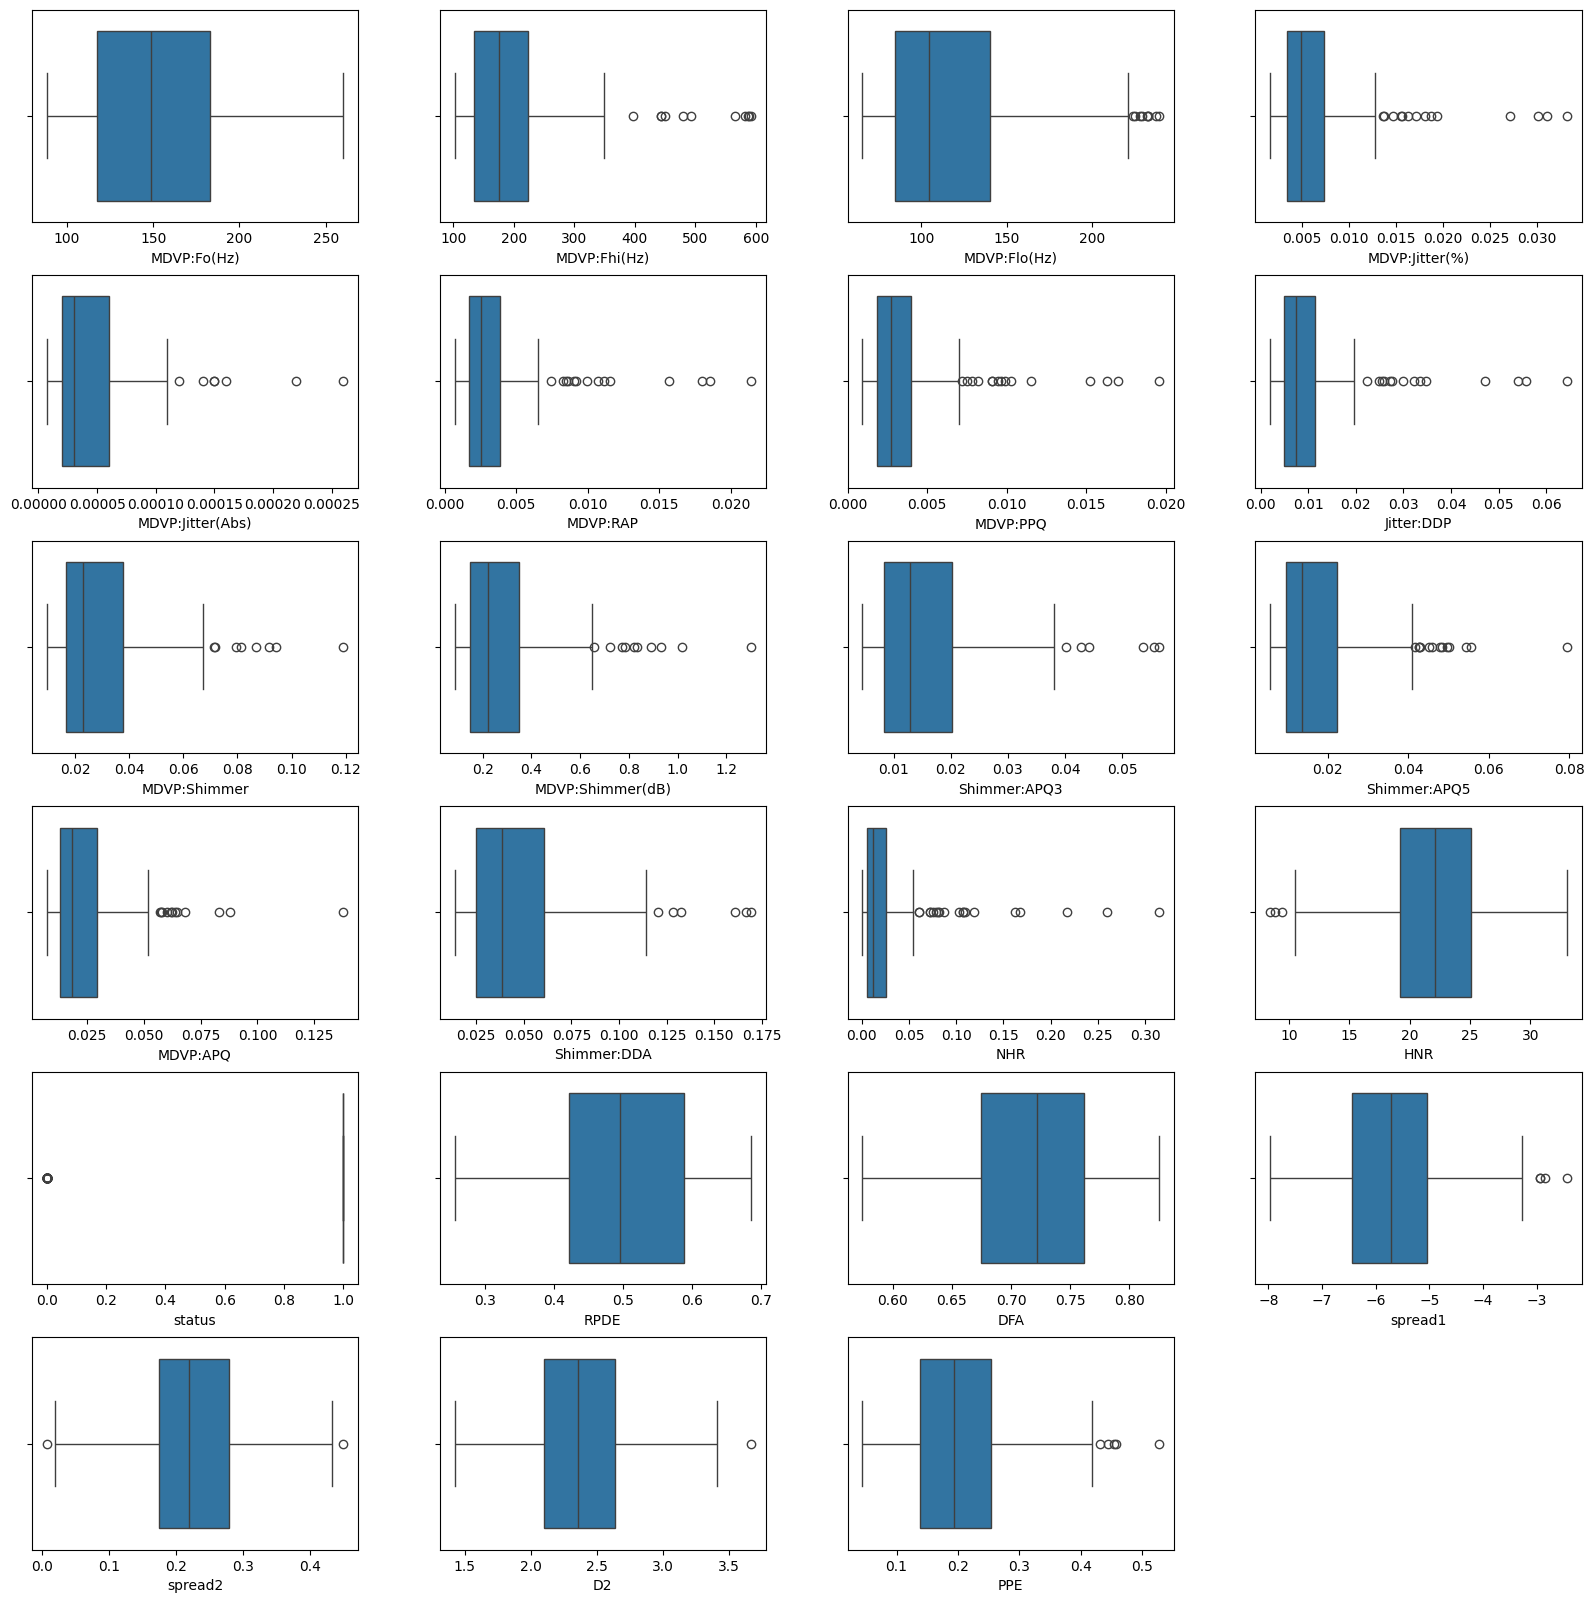

In [8]:
plt.figure(figsize=(20,20))
df_cols = df.columns[1:]
index = 0
for col in df_cols:
  index += 1
  plt.subplot(6,4,index)
  plt.subplots_adjust(hspace=0.25, wspace=0.25)
  sns.boxplot(x = df[col])

Most of the columns have outliers but due to the data being health care dataset it is very sensitive so we'll be avoiding removing them.

In [9]:
# # Let's check for correlation in the dataset
# plt.figure(figsize=(15, 8))
# sns.heatmap(df.corr(numeric_only=True)>0.9, annot=True)
# plt.show()

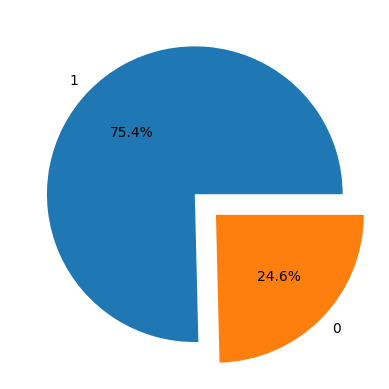

In [10]:
x = df['status'].value_counts()
plt.pie(x.values,
		labels = x.index,
		autopct='%1.1f%%',
        explode = [0,0.2])
plt.show()


In [11]:
#feature extraction
x = df.drop(columns=['name','status'], axis=1)
y = df['status']

x.shape, y.shape

((195, 22), (195,))

In [12]:
#EDA2
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((156, 22), (39, 22), (156,), (39,))

In [13]:
#Let's implement Random Over Sampling to balance the data.

from imblearn.over_sampling import RandomOverSampler
# As the data was highly imbalanced we will balance
# it by adding repetitive rows of minority class.
ros = RandomOverSampler(sampling_strategy='minority', random_state=24)
print("Before : ",x_train.shape, y_train.shape)
x_train, y_train = ros.fit_resample(x_train, y_train)
print("After : ",x_train.shape, y_train.shape)


Before :  (156, 22) (156,)
After :  (230, 22) (230,)


In [17]:
#model building
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

models = [LogisticRegression(),SVC(kernel='rbf'),XGBClassifier()]
fitted_models=[]
for model in models:
  model.fit(x_train, y_train)
  print(model.__class__.__name__)
  print("Training Accuracy : ",roc_auc_score(y_train, model.predict(x_train)))
  print("Testing Accuracy : ",roc_auc_score(y_test, model.predict(x_test)))
  print()

LogisticRegression
Training Accuracy :  0.8
Testing Accuracy :  0.7232142857142857

SVC
Training Accuracy :  0.7869565217391304
Testing Accuracy :  0.5736607142857143

XGBClassifier
Training Accuracy :  1.0
Testing Accuracy :  0.8571428571428572



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


We can see that LogisticRegression and XGBClassifier are performing good but XGBClassifier is pruned to overfitting because it is performing extremely well in Training data and not so well in Testing data.

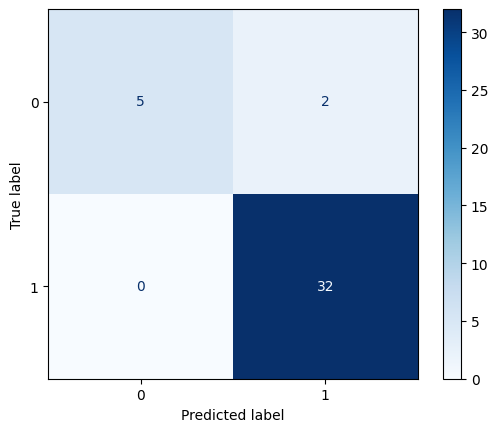

In [23]:
#Let's plot confusion matrix and classification report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')

In [24]:
print(classification_report(y_test, model.predict(x_test)))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



We can see the model is performing decent.

Thank you so much for going through my work till the end, feel free to get in touch if you have any questions... :)